In [1]:
#Diable the warnings
import warnings
warnings.filterwarnings('ignore')

In [2]:
pip install yfinance


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [611]:
import yfinance as yf

wti = yf.download("CL=F", start="1983-01-01", end="2026-04-30")
brent = yf.download("BZ=F", start="1988-01-01", end="2026-05-02")
vix = yf.download("^VIX", start="2000-01-01")
dxy = yf.download("DX-Y.NYB", start="2000-01-01")
vix = vix["Close"]
dxy = dxy["Close"]
print(dxy.head())

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

Ticker        DX-Y.NYB
Date                  
2000-01-03  100.220001
2000-01-04  100.410004
2000-01-05  100.379997
2000-01-06  100.650002
2000-01-07  100.800003


In [612]:
import pandas as pd

invoil = pd.read_excel("InvOil.xls")   # یا .xlsx
invoil["date"] = pd.to_datetime(invoil["Date"])
invoil = invoil.set_index("date")
del invoil["Date"]
invoil = invoil.rename(columns={'Weekly U.S. Ending Stocks excluding SPR of Crude Oil  (Thousand Barrels)': 'Stocks'})
del invoil["Weekly U.S. Ending Stocks of Crude Oil  (Thousand Barrels)"]
invoil.head()

,Stocks
date,
1982-08-20,338764
1982-08-27,336138
1982-09-24,335586
1982-10-01,334786
1982-10-08,335260


In [614]:
# ساخت daily index
daily_index = pd.date_range(
    start=invoil.index.min(),
    end=invoil.index.max(),
    freq="D"
)

df_daily = invoil.reindex(daily_index)

# پر کردن مقادیر هفتگی برای روزهای بین
df_daily = df_daily.ffill()
df_daily=df_daily.reset_index()
df_daily.columns = ["date", "Stocks"]

df_daily

,date,Stocks
0,1982-08-20,338764.0
1,1982-08-21,338764.0
2,1982-08-22,338764.0
3,1982-08-23,338764.0
4,1982-08-24,338764.0
...,...,...
15970,2026-05-11,452876.0
15971,2026-05-12,452876.0
15972,2026-05-13,452876.0
15973,2026-05-14,452876.0


In [615]:
gpr = pd.read_excel("data_gpr_daily_recent.xls")
gpr.to_csv("gpr.csv", index=False)
gpr = pd.read_csv("gpr.csv", parse_dates=['date'])
gpr=gpr[['date','GPRD','GPRD_ACT','GPRD_THREAT']]
gpr

,date,GPRD,GPRD_ACT,GPRD_THREAT
0,1985-01-01,230.039429,275.197601,153.027985
1,1985-01-02,115.676971,146.772064,87.444572
2,1985-01-03,97.428459,158.937653,29.459934
3,1985-01-04,157.366638,156.882248,157.026352
4,1985-01-05,81.361313,92.698143,77.319405
...,...,...,...,...
15087,2026-04-23,238.982849,304.427032,287.042480
15088,2026-04-24,262.010986,236.327881,331.992920
15089,2026-04-25,201.576126,227.749741,178.791321
15090,2026-04-26,167.390396,228.355453,190.471008


In [349]:
import yfinance as yf
import pandas as pd
import numpy as np
from scipy.stats import skew, kurtosis, jarque_bera
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch

# =========================
# 1. دانلود داده
# =========================

wti = yf.download("CL=F", start="1983-01-01", end="2026-04-28")
brent = yf.download("BZ=F", start="1988-01-01", end="2026-04-28")
vix = yf.download("^VIX", start="2000-01-01",end="2026-04-28")
dxy = yf.download("DX-Y.NYB", start="2000-01-01",end="2026-04-28")
vix = vix["Close"]
dxy = dxy["Close"]
# =========================
# 2. فقط ستون Close + rename
# =========================

wti = wti[["Close"]].rename(columns={"Close": "WTI"})
brent = brent[["Close"]].rename(columns={"Close": "Brent"})
vix = vix.rename(columns={"Close": "vix"})
dxy = dxy.rename(columns={"Close": "dxy"})
gpr=gpr.set_index("date")
gpr=gpr[["GPRD_ACT","GPRD_THREAT"]]
df_daily=df_daily.set_index("date")
# =========================
# 3. merge بر اساس تاریخ
# =========================

data = pd.concat([wti, brent, vix, dxy,gpr,df_daily], axis=1, join="inner")
# =========================
# 4. حذف NA
# =========================

data = data.dropna()

# =========================
# 5. ساخت بازدهی
# =========================
returns=data
#returns = np.log(data / data.shift(1)).dropna()
returns["WTI_ret"]=np.log(returns[('WTI', 'CL=F')] / returns[('WTI', 'CL=F')].shift(1)).dropna()
returns["Brent_ret"]=np.log(returns[('Brent', 'BZ=F')] / returns[('Brent', 'BZ=F')].shift(1)).dropna()
#returns.columns = ["WTI_ret", "Brent_ret","vix","dxy","GPRD_ACT","GPRD_THREAT"]
returns=returns[["WTI_ret", "Brent_ret","^VIX","DX-Y.NYB","GPRD_ACT","GPRD_THREAT","Stocks"]].dropna()
returns.columns = ["WTI_ret", "Brent_ret","vix","dxy","GPRD_ACT","GPRD_THREAT","Stocks"]
print(returns.head())

# =========================
# 4. تابع آمار توصیفی
# =========================

def descriptive_stats(series):
    return pd.Series({
        "Mean": series.mean(),
        "Std": series.std(),
        "Min": series.min(),
        "Max": series.max(),
        "Skewness": skew(series),
        "Kurtosis": kurtosis(series),
        "JB_stat": jarque_bera(series)[0],
        "JB_pvalue": jarque_bera(series)[1]
    })

desc_table = returns.apply(descriptive_stats)

print("\n=== Descriptive Statistics ===")
print(desc_table.T)

# =========================
# 5. آزمون ADF (ریشه واحد)
# =========================

def adf_test(series):
    result = adfuller(series)
    return {
        "ADF_stat": result[0],
        "p-value": result[1]
    }

print("\n=== ADF Test ===")
for col in returns.columns:
    res = adf_test(returns[col])
    print(f"{col}: {res}")

# =========================
# 6. Ljung-Box (خودهمبستگی)
# =========================

print("\n=== Ljung-Box Test (lag=10) ===")
for col in returns.columns:
    lb = acorr_ljungbox(returns[col], lags=[10], return_df=True)
    print(f"\n{col}")
    print(lb)

# =========================
# 7. ARCH LM test
# =========================

print("\n=== ARCH LM Test ===")
for col in returns.columns:
    arch_test = het_arch(returns[col])
    print(f"{col}: LM Stat={arch_test[0]}, p-value={arch_test[1]}")

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


             WTI_ret  Brent_ret        vix        dxy    GPRD_ACT  \
2007-07-31  0.017802   0.017148  23.520000  80.769997  115.872681   
2007-08-01 -0.021715  -0.022311  23.670000  80.870003  149.811707   
2007-08-02  0.004303   0.005427  21.219999  80.709999  106.623642   
2007-08-03 -0.018118  -0.013421  25.160000  80.180000  143.853287   
2007-08-06 -0.046369  -0.049078  22.940001  80.250000  123.165367   

            GPRD_THREAT    Stocks  
2007-07-31   130.760757  327287.0  
2007-08-01   108.658928  327287.0  
2007-08-02    88.934647  327287.0  
2007-08-03   114.770996  323326.0  
2007-08-06    89.890564  323326.0  

=== Descriptive Statistics ===
                      Mean           Std            Min            Max  \
WTI_ret           0.000178      0.027327      -0.282206       0.319634   
Brent_ret         0.000157      0.023725      -0.275751       0.190774   
vix              19.918658      8.699425       9.140000      82.690002   
dxy              91.099122     10.045024 

In [616]:
import numpy as np
import pandas as pd

def parkinson_daily(df):
    log_hl = np.log(df['High'] / df['Low'])
    sigma_daily = np.sqrt((log_hl ** 2) / (4 * np.log(2)))
    return sigma_daily

In [617]:
def yang_zhang_rolling(df, window):

    df = df.copy()

    log_ho = np.log(df['High'] / df['Open'])
    log_lo = np.log(df['Low'] / df['Open'])
    log_co = np.log(df['Close'] / df['Open'])

    log_oc = np.log(df['Open'] / df['Close'].shift(1))
    log_cc = np.log(df['Close'] / df['Close'].shift(1))

    rs = log_ho * (log_ho - log_co) + log_lo * (log_lo - log_co)

    sigma_o = log_oc.rolling(window).var()
    sigma_c = log_cc.rolling(window).var()
    sigma_rs = rs.rolling(window).mean()

    k = 0.34 / (1.34 + (window + 1)/(window - 1))

    yz_var = sigma_o + k * sigma_c + (1 - k) * sigma_rs

    return np.sqrt(yz_var)

In [618]:
# فرض: df داری با OHLC
wti['YZ_vol'] =  yang_zhang_rolling(wti, window=30)



In [619]:
wti['Parkinson_daily'] = parkinson_daily(wti)

In [620]:
wti.columns = wti.columns.get_level_values(0)

wti=pd.DataFrame(wti[['YZ_vol','Parkinson_daily','Close']], columns=['YZ_vol','Parkinson_daily','Close'])
wti.head(2000)

,YZ_vol,Parkinson_daily,Close
Date,,,
2000-08-23,NaN,0.015769,32.049999
2000-08-24,NaN,0.015855,31.629999
2000-08-25,NaN,0.014773,32.049999
2000-08-28,NaN,0.019656,32.869999
2000-08-29,NaN,0.008607,32.720001
...,...,...,...
2008-08-15,0.024517,0.020468,113.769997
2008-08-18,0.024394,0.017700,112.870003
2008-08-19,0.024524,0.026364,114.529999


In [396]:
pip install xlrd==2.0.1

In [621]:
gpr = pd.read_excel("data_gpr_daily_recent.xls")
gpr.to_csv("gpr.csv", index=False)
gpr = pd.read_csv("gpr.csv", parse_dates=['date'])
gpr=gpr[['date','GPRD','GPRD_ACT','GPRD_THREAT']]
gpr

,date,GPRD,GPRD_ACT,GPRD_THREAT
0,1985-01-01,230.039429,275.197601,153.027985
1,1985-01-02,115.676971,146.772064,87.444572
2,1985-01-03,97.428459,158.937653,29.459934
3,1985-01-04,157.366638,156.882248,157.026352
4,1985-01-05,81.361313,92.698143,77.319405
...,...,...,...,...
15087,2026-04-23,238.982849,304.427032,287.042480
15088,2026-04-24,262.010986,236.327881,331.992920
15089,2026-04-25,201.576126,227.749741,178.791321
15090,2026-04-26,167.390396,228.355453,190.471008


In [622]:
wti1=wti.reset_index()
wti2 =wti1.rename(columns={'Date': 'date'})
datag = wti2.merge(gpr, on='date', how='inner')
vix=vix.reset_index()
vix = vix.rename(columns={'Date': 'date'})
datagg = datag .merge(vix, on='date', how='inner')
dxy=dxy.reset_index()
dxy = dxy.rename(columns={'Date': 'date'})
dataggg = datagg .merge(dxy, on='date', how='inner')
data = dataggg .merge(invoil, on='date', how='inner').dropna()
data

,date,YZ_vol,Parkinson_daily,Close,GPRD,GPRD_ACT,GPRD_THREAT,^VIX,DX-Y.NYB,Stocks
6,2000-10-06,0.031326,0.008006,30.850000,82.246971,28.273727,117.915405,22.709999,114.849998,271752
7,2000-10-13,0.034324,0.017969,35.049999,195.977707,287.634644,176.541748,27.600000,115.860001,267235
8,2000-10-20,0.035363,0.026815,34.299999,57.729397,60.292259,59.433277,24.240000,117.160004,269640
9,2000-10-27,0.035162,0.018831,32.700001,35.326809,32.508987,31.634989,26.469999,117.389999,268151
10,2000-11-03,0.029946,0.010682,32.599998,75.163612,64.227646,89.286995,23.670000,114.970001,266594
...,...,...,...,...,...,...,...,...,...,...
1279,2026-03-20,0.072263,0.038892,98.320000,308.658539,406.614746,274.992065,26.780001,99.650002,456185
1280,2026-03-27,0.076379,0.056955,99.639999,286.611511,439.583527,229.160049,31.049999,100.150002,461636
1281,2026-04-10,0.082652,0.030106,96.570000,341.627625,364.902893,294.219574,19.230000,98.650002,463804
1282,2026-04-17,0.081783,0.092918,83.849998,328.272461,368.913544,317.636475,17.480000,98.099998,465729


In [461]:
gpr1=gpr.set_index('date')
brent3=brent2.set_index('date')

brent3

,YZ_vol,Parkinson_daily,Close
date,,,
2007-07-30,NaN,0.008615,75.739998
2007-07-31,NaN,0.011788,77.050003
2007-08-01,NaN,0.017395,75.349998
2007-08-02,NaN,0.015486,75.760002
2007-08-03,NaN,0.011730,74.750000
...,...,...,...
2026-04-27,0.060958,0.021948,108.230003
2026-04-28,0.060716,0.025975,111.260002
2026-04-29,0.061080,0.052610,118.029999


In [462]:
data = brent3.join(gpr1, how='inner')
data=data.dropna()
data

,YZ_vol,Parkinson_daily,Close,GPRD,GPRD_ACT,GPRD_THREAT
date,,,,,,
2007-09-11,0.014627,0.011187,76.379997,105.618103,76.576729,138.390533
2007-09-12,0.014653,0.012235,77.680000,99.830803,90.475922,100.621140
2007-09-13,0.014585,0.007664,77.120003,124.077011,172.597809,91.176956
2007-09-14,0.014416,0.009167,76.220001,85.012802,111.053192,63.377964
2007-09-17,0.014304,0.011809,76.980003,44.764431,0.000000,74.446053
...,...,...,...,...,...,...
2026-04-21,0.067065,0.044858,98.480003,183.639145,126.743462,258.418274
2026-04-22,0.062865,0.034863,101.910004,225.706024,225.011276,231.842010
2026-04-23,0.061844,0.035012,105.070000,238.982849,304.427032,287.042480


In [46]:
pip install arch


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [623]:
data['ret'] = np.log(data['Close'] / data['Close'].shift(1))
data=data.dropna()
data

,date,YZ_vol,Parkinson_daily,Close,GPRD,GPRD_ACT,GPRD_THREAT,^VIX,DX-Y.NYB,Stocks,ret
7,2000-10-13,0.034324,0.017969,35.049999,195.977707,287.634644,176.541748,27.600000,115.860001,267235,0.127639
8,2000-10-20,0.035363,0.026815,34.299999,57.729397,60.292259,59.433277,24.240000,117.160004,269640,-0.021630
9,2000-10-27,0.035162,0.018831,32.700001,35.326809,32.508987,31.634989,26.469999,117.389999,268151,-0.047770
10,2000-11-03,0.029946,0.010682,32.599998,75.163612,64.227646,89.286995,23.670000,114.970001,266594,-0.003063
11,2000-11-10,0.026758,0.009751,34.090000,33.775200,56.982094,21.603952,28.530001,115.790001,268091,0.044692
...,...,...,...,...,...,...,...,...,...,...,...
1279,2026-03-20,0.072263,0.038892,98.320000,308.658539,406.614746,274.992065,26.780001,99.650002,456185,-0.003959
1280,2026-03-27,0.076379,0.056955,99.639999,286.611511,439.583527,229.160049,31.049999,100.150002,461636,0.013336
1281,2026-04-10,0.082652,0.030106,96.570000,341.627625,364.902893,294.219574,19.230000,98.650002,463804,-0.031296
1282,2026-04-17,0.081783,0.092918,83.849998,328.272461,368.913544,317.636475,17.480000,98.099998,465729,-0.141239


In [624]:
from arch import arch_model

model = arch_model(
    data['ret'] ,
    mean='Constant',
    vol='EGARCH',
    p=1, o=1, q=1,   # o = asymmetry term
    dist='normal'
)

res = model.fit()
print(res.summary())

# استخراج ولاتیلیتی شرطی
egarch_vol = res.conditional_volatility

# اضافه کردن به دیتا فریم
data = data.copy()
data["EGARCH_vol"] = egarch_vol

print(data[["ret", "EGARCH_vol"]].head())

Iteration:      1,   Func. Count:      7,   Neg. LLF: 282708697436339.2
Iteration:      2,   Func. Count:     19,   Neg. LLF: 94405630533.29407
Iteration:      3,   Func. Count:     29,   Neg. LLF: 1179985579950.0015
Iteration:      4,   Func. Count:     38,   Neg. LLF: 738699456.279785
Iteration:      5,   Func. Count:     48,   Neg. LLF: -1812.4528445081623
Iteration:      6,   Func. Count:     57,   Neg. LLF: -1990.1131543764932
Iteration:      7,   Func. Count:     64,   Neg. LLF: -1996.8586704856766
Iteration:      8,   Func. Count:     70,   Neg. LLF: -1996.8616502523867
Iteration:      9,   Func. Count:     76,   Neg. LLF: -1996.8618234691164
Iteration:     10,   Func. Count:     82,   Neg. LLF: -1996.861830909485
Iteration:     11,   Func. Count:     87,   Neg. LLF: -1996.861830908232
Optimization terminated successfully    (Exit mode 0)
            Current function value: -1996.861830909485
            Iterations: 11
            Function evaluations: 87
            Gradient ev

In [625]:
from statsmodels.stats.diagnostic import acorr_ljungbox

std_resid = res.std_resid

acorr_ljungbox(std_resid, lags=[10], return_df=True)

,lb_stat,lb_pvalue
10,13.529528,0.195553


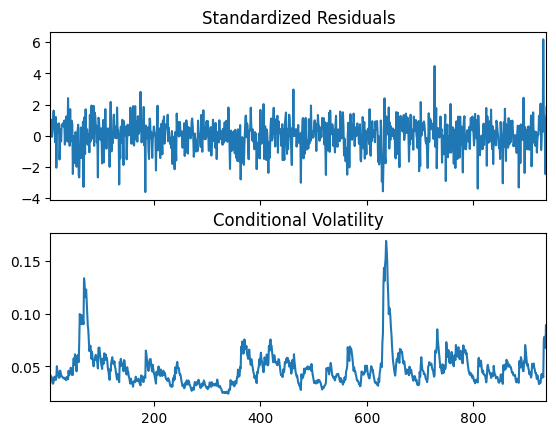

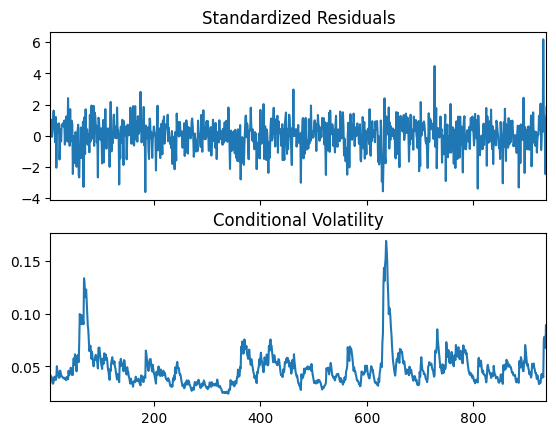

In [364]:
res.plot()

In [626]:
from statsmodels.stats.diagnostic import het_arch

het_arch(res.std_resid)

(7.763275628163551, 0.651947284155519, 0.7743225478864306, 0.6538255221219673)

In [ ]:
pip install pymc

In [627]:
import pymc as pm
import numpy as np

returns = data['ret'].values

with pm.Model() as model:

    sigma = pm.Exponential("sigma", 2.0)
    phi = pm.Beta("phi", 20, 1)   # نزدیک به 1

    h = pm.AR("h", rho=phi, sigma=sigma, shape=len(returns))

    r = pm.Normal("r", mu=0, sigma=np.exp(h/2), observed=returns)

    trace = pm.sample(
        draws=200,
        tune=100,
        chains=4,
        target_accept=0.95)


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 2 jobs)
NUTS: [sigma, phi, h]


Sampling 4 chains for 100 tune and 200 draw iterations (400 + 800 draws total) took 97 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


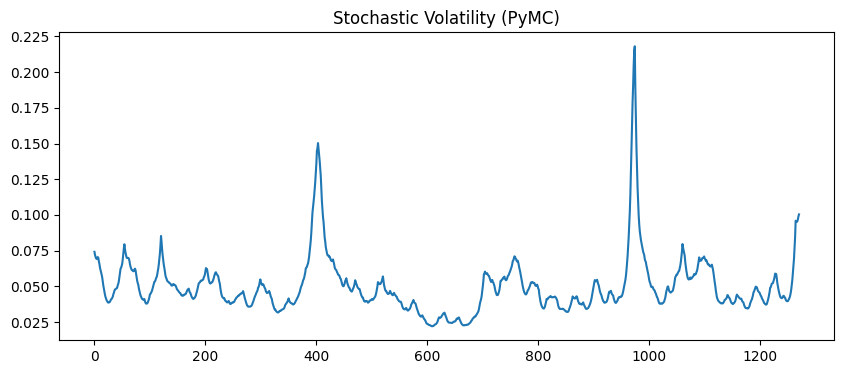

In [628]:
h_post = trace.posterior["h"]
volatility = np.exp(h_post / 2)
vol_mean = volatility.mean(dim=("chain","draw")).values
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(vol_mean)
plt.title("Stochastic Volatility (PyMC)")
plt.show()

In [629]:
data["SV_vol"] = vol_mean
data

,date,YZ_vol,Parkinson_daily,Close,GPRD,GPRD_ACT,GPRD_THREAT,^VIX,DX-Y.NYB,Stocks,ret,EGARCH_vol,SV_vol
7,2000-10-13,0.034324,0.017969,35.049999,195.977707,287.634644,176.541748,27.600000,115.860001,267235,0.127639,0.061345,0.074148
8,2000-10-20,0.035363,0.026815,34.299999,57.729397,60.292259,59.433277,24.240000,117.160004,269640,-0.021630,0.065249,0.072010
9,2000-10-27,0.035162,0.018831,32.700001,35.326809,32.508987,31.634989,26.469999,117.389999,268151,-0.047770,0.061377,0.070581
10,2000-11-03,0.029946,0.010682,32.599998,75.163612,64.227646,89.286995,23.670000,114.970001,266594,-0.003063,0.062384,0.069700
11,2000-11-10,0.026758,0.009751,34.090000,33.775200,56.982094,21.603952,28.530001,115.790001,268091,0.044692,0.056292,0.069145
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1279,2026-03-20,0.072263,0.038892,98.320000,308.658539,406.614746,274.992065,26.780001,99.650002,456185,-0.003959,0.067645,0.095091
1280,2026-03-27,0.076379,0.056955,99.639999,286.611511,439.583527,229.160049,31.049999,100.150002,461636,0.013336,0.060697,0.095521
1281,2026-04-10,0.082652,0.030106,96.570000,341.627625,364.902893,294.219574,19.230000,98.650002,463804,-0.031296,0.055598,0.096913
1282,2026-04-17,0.081783,0.092918,83.849998,328.272461,368.913544,317.636475,17.480000,98.099998,465729,-0.141239,0.055059,0.098957


In [630]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
data = data.rename(columns={'^VIX': 'vix'})
data = data.rename(columns={'DX-Y.NYB': 'dxy'})
# ستون‌هایی که می‌خواهیم پردازش کنیم
cols = ["GPRD", "GPRD_ACT", "GPRD_THREAT","vix", "dxy","Stocks"]

# 1️⃣ ایجاد lag یک روزه
for col in cols:
    data[f"{col}_lag1"] = data[col].shift(1)

# 2️⃣ ایجاد growth rate روزانه
for col in cols:
    data[f"{col}_growth"] = data[col].pct_change()  # (today - yesterday)/yesterday

# 3️⃣ استانداردسازی/نرمال‌سازی
# ستون های اصلی، lag و growth را با هم استاندارد می‌کنیم
standard_cols = cols + [f"{c}_lag1" for c in cols]

scaler = StandardScaler()
data[standard_cols] = scaler.fit_transform(data[standard_cols])

# نمایش چند ردیف اول
data.head()

,date,YZ_vol,Parkinson_daily,Close,GPRD,GPRD_ACT,GPRD_THREAT,vix,dxy,Stocks,...,GPRD_THREAT_lag1,vix_lag1,dxy_lag1,Stocks_lag1,GPRD_growth,GPRD_ACT_growth,GPRD_THREAT_growth,vix_growth,dxy_growth,Stocks_growth
7,2000-10-13,0.034324,0.017969,35.049999,1.154676,1.642126,0.823279,0.955746,2.119575,-1.390777,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,2000-10-20,0.035363,0.026815,34.299999,-0.884183,-0.551050,-0.893036,0.557535,2.237268,-1.358864,...,0.828540,0.955296,2.119425,-1.390053,-0.705429,-0.790386,-0.663347,-0.121739,0.011220,0.009000
9,2000-10-27,0.035162,0.018831,32.700001,-1.214572,-0.819075,-1.300441,0.821823,2.258090,-1.378622,...,-0.893634,0.557240,2.237085,-1.358136,-0.388062,-0.460810,-0.467723,0.091997,0.001963,-0.005522
10,2000-11-03,0.029946,0.010682,32.599998,-0.627067,-0.513085,-0.455506,0.489981,2.039001,-1.399282,...,-1.302430,0.821426,2.257901,-1.377897,1.127665,0.975689,1.822413,-0.105780,-0.020615,-0.005806
11,2000-11-10,0.026758,0.009751,34.090000,-1.237455,-0.582983,-1.447454,1.065965,2.113238,-1.379418,...,-0.454611,0.489713,2.038873,-1.398560,-0.550644,-0.112810,-0.758039,0.205323,0.007132,0.005615


In [632]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = data[['GPRD_ACT','GPRD_THREAT',
          'GPRD_ACT_lag1','GPRD_THREAT_lag1',"vix", "dxy","Stocks"]].dropna()

vif = pd.DataFrame()
vif["Variable"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i)
              for i in range(X.shape[1])]

print(vif)

           Variable       VIF
0          GPRD_ACT  2.389793
1       GPRD_THREAT  1.946708
2     GPRD_ACT_lag1  2.348520
3  GPRD_THREAT_lag1  1.963337
4               vix  1.057154
5               dxy  1.321610
6            Stocks  1.364684


In [658]:
import statsmodels.formula.api as smf
data = data.rename(columns={'^VIX': 'vix'})
data = data.rename(columns={'DX-Y.NYB': 'dxy'})
model = smf.quantreg('EGARCH_vol	~ GPRD_THREAT + GPRD_ACT + vix + dxy + GPRD_THREAT_lag1 + GPRD_ACT_lag1 +Stocks', data)
res = model.fit(q=0.75)
print(res.summary())

                         QuantReg Regression Results                          
Dep. Variable:             EGARCH_vol   Pseudo R-squared:               0.1704
Model:                       QuantReg   Bandwidth:                    0.003493
Method:                 Least Squares   Sparsity:                      0.03273
Date:                Thu, 21 May 2026   No. Observations:                 1270
Time:                        23:08:38   Df Residuals:                     1262
                                        Df Model:                            7
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept            0.0566      0.000    142.070      0.000       0.056       0.057
GPRD_THREAT         -0.0018      0.001     -3.341      0.001      -0.003      -0.001
GPRD_ACT             0.0013      0.001      2.101      0.036    8.49e-05       0.002
vix                  0

In [641]:
data.to_csv("data.csv")

In [642]:
import numpy as np
import pandas as pd
from itertools import combinations

In [659]:
df = pd.read_csv("data.csv").dropna()
df = df.copy()
df=df.reset_index()
# 🔥 استفاده از ستون واقعی date (خیلی مهم)
df["date"] = pd.to_datetime(df["date"])
df = df.set_index("date")

# حذف timezone اگر وجود دارد
df.index = df.index.tz_localize(None)

# مرتب‌سازی زمانی
df = df.sort_index()

df = df.loc[:"2025-09-21"]
y = df["SV_vol"].values
X = df[["GPRD_THREAT", "GPRD_ACT",'GPRD_ACT_lag1','GPRD_THREAT_lag1',"vix", "dxy","Stocks"]].values

T, k = X.shape

In [660]:
model_list = []

for i in range(1, k+1):
    for combo in combinations(range(k), i):
        model_list.append(list(combo))

M = len(model_list)


In [661]:
alpha = 0.99      # model forgetting
lambda_ = 0.99    # parameter forgetting

weights = np.ones(M) / M

y_hat = np.zeros(T)
weights_time = np.zeros((T, M))

In [662]:
theta = []
P = []

for m in range(M):
    p = len(model_list[m]) + 1
    theta.append(np.zeros((p,1)))
    P.append(np.eye(p) * 1000)

In [663]:
for t in range(1, T):

    pred = np.zeros(M)
    loglik = np.zeros(M)

    for m in range(M):

        idx = model_list[m]

        x_tm1 = np.concatenate(([1], X[t-1, idx])).reshape(-1,1)

        th = theta[m]
        Pm = P[m]

        # prediction
        y_pred = float(x_tm1.T @ th)
        pred[m] = y_pred

        # error
        e = y[t] - y_pred

        # variance (adaptive)
        sigma2 = e**2 + 1e-6

        # Kalman gain (stable)
        S = lambda_ + (x_tm1.T @ Pm @ x_tm1)[0,0]
        K = (Pm @ x_tm1) / S

        # update theta
        th_new = th + K * e

        # Joseph form (numerical stability)
        I = np.eye(Pm.shape[0])
        P_new = (I - K @ x_tm1.T) @ Pm @ (I - K @ x_tm1.T).T + K * sigma2 * K.T
        P_new = P_new / lambda_

        theta[m] = th_new
        P[m] = P_new

        # log-likelihood (important!)
        loglik[m] = -0.5*(np.log(2*np.pi*sigma2) + (e**2)/sigma2)

    # 🔥 log-weight update (stable)
    logw = alpha * np.log(weights + 1e-12) + loglik
    logw = logw - np.max(logw)

    weights = np.exp(logw)
    weights = weights / np.sum(weights)

    # DMA prediction
    y_hat[t] = np.sum(weights * pred)
    weights_time[t,:] = weights

In [664]:
importance = np.zeros((T, k))

for t in range(T):
    for j in range(k):
        importance[t,j] = np.sum(
            weights_time[t,:] *
            np.array([j in model for model in model_list])
        )

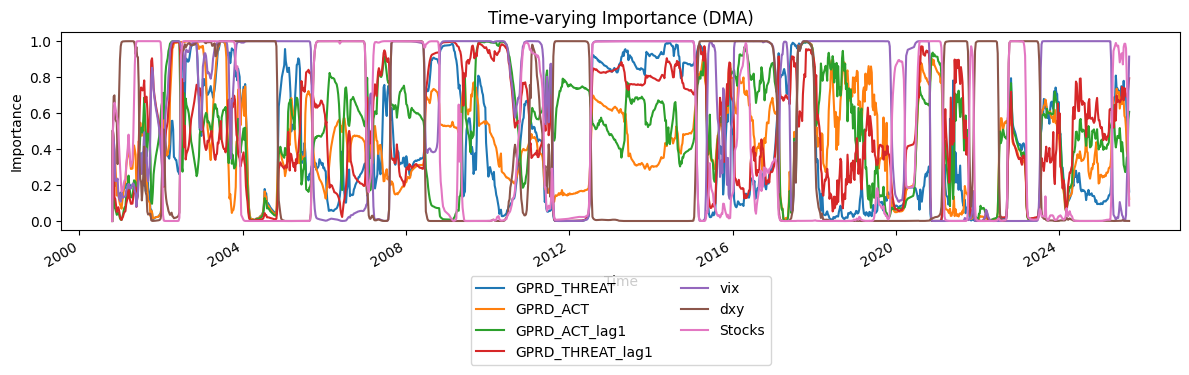

In [665]:
import matplotlib.pyplot as plt
import pandas as pd

# =========================
# 1. تاریخ واقعی
# =========================

dates = pd.to_datetime(df.index)

# =========================
# 2. رسم نمودار
# =========================

plt.figure(figsize=(12,4))

var_names = ["GPRD_THREAT", "GPRD_ACT",'GPRD_ACT_lag1','GPRD_THREAT_lag1',"vix", "dxy","Stocks"]

for j in range(k):
    plt.plot(dates, importance[:, j], label=var_names[j])

# =========================
# 3. فرمت محور زمان
# =========================

plt.gcf().autofmt_xdate()

plt.title("Time-varying Importance (DMA)")
plt.xlabel("Time")
plt.ylabel("Importance")

plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), ncol=2)
plt.tight_layout()
plt.savefig("figure.png", dpi=300, bbox_inches='tight')
plt.show()

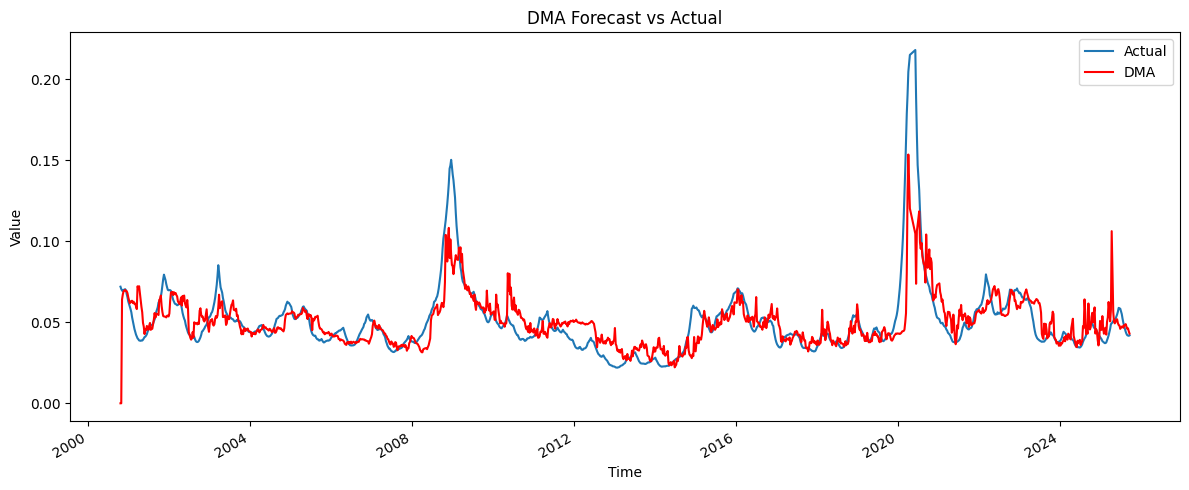

In [666]:
import matplotlib.pyplot as plt
import pandas as pd

# =========================
# 1. اطمینان از تاریخ درست
# =========================

dates = pd.to_datetime(df.index)

# =========================
# 2. رسم نمودار
# =========================

plt.figure(figsize=(12,5))

plt.plot(dates, y, label="Actual")
plt.plot(dates, y_hat, label="DMA", color="red")

# =========================
# 3. فرمت تاریخ محور X
# =========================

plt.gcf().autofmt_xdate()  # چرخش خودکار تاریخ‌ها

plt.title("DMA Forecast vs Actual")
plt.xlabel("Time")
plt.ylabel("Value")

plt.legend()
plt.tight_layout()
plt.savefig("5.png", dpi=300, bbox_inches='tight')
plt.show()

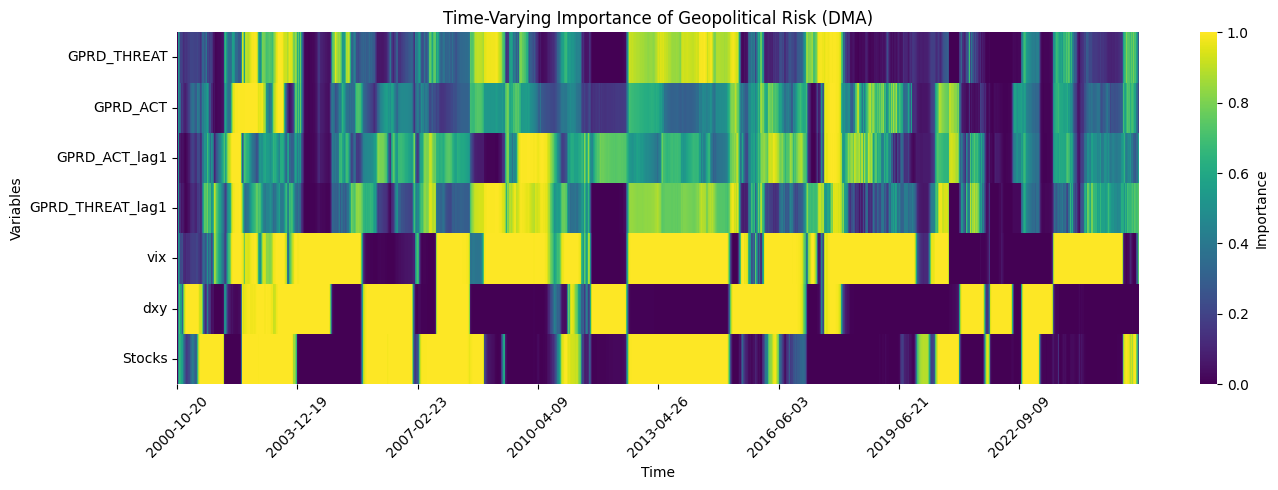

In [667]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# =========================
# 1. ساخت صحیح DataFrame (اول این باید باشد)
# =========================

var_names = ["GPRD_THREAT", "GPRD_ACT",'GPRD_ACT_lag1','GPRD_THREAT_lag1',"vix", "dxy","Stocks"]

importance_df = pd.DataFrame(
    importance,
    columns=var_names,
    index=pd.to_datetime(df.index)
)

# حذف میلی‌ثانیه/نانوثانیه (تمیز کردن تاریخ)
importance_df.index = importance_df.index.floor('D')

# =========================
# 2. رسم heatmap
# =========================

plt.figure(figsize=(14,5))

ax = sns.heatmap(
    importance_df.T,
    cmap="viridis",
    cbar_kws={'label': 'Importance'},
    xticklabels=False   # جلوگیری از بهم‌ریختگی
)

# =========================
# 3. تنظیم محور X به تاریخ واقعی
# =========================

step = max(1, len(importance_df)//8)  # فقط 8 تا لیبل تمیز

plt.xticks(
    ticks=[i for i in range(0, len(importance_df), step)],
    labels=importance_df.index[::step].strftime('%Y-%m-%d'),
    rotation=45
)

# =========================
# 4. لیبل‌ها
# =========================

plt.title("Time-Varying Importance of Geopolitical Risk (DMA)")
plt.xlabel("Time")
plt.ylabel("Variables")

plt.tight_layout()
plt.savefig("figure2.png", dpi=300, bbox_inches='tight')
plt.show()

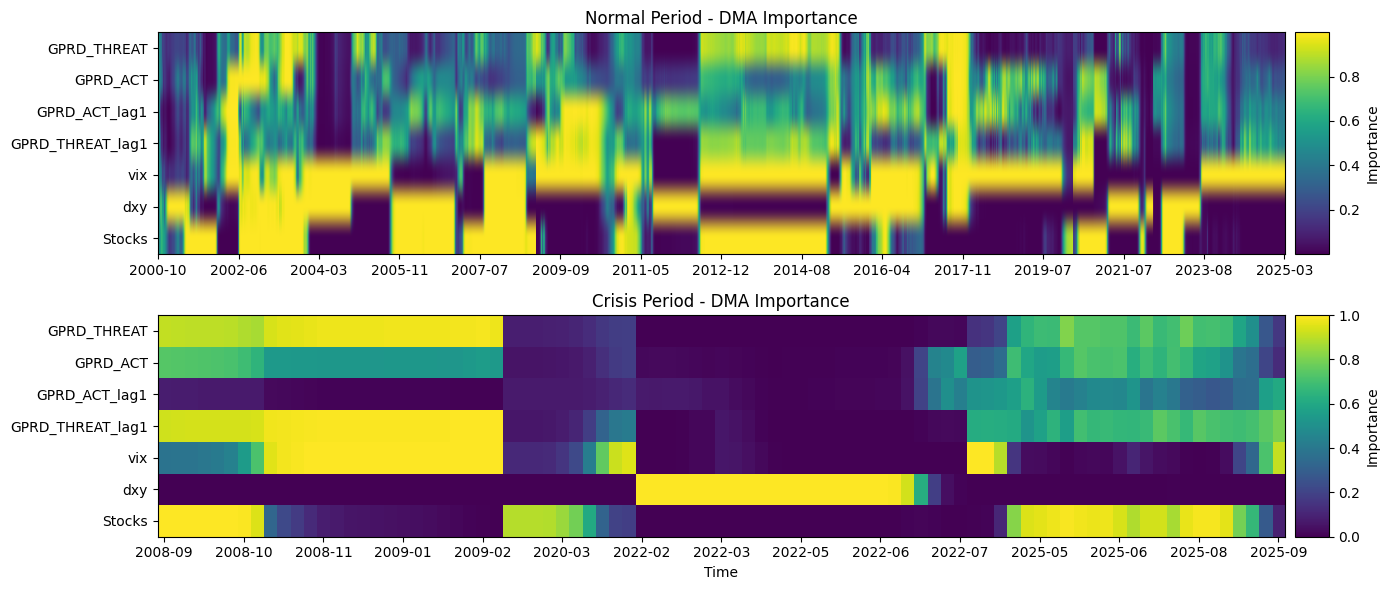

In [668]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================================================
# 1. FIX تاریخ (درست)
# =========================================================

df = df.copy()
df = df.reset_index()

df["date"] = pd.to_datetime(df["date"])
df = df.set_index("date")
df.index = df.index.tz_localize(None)
df = df.sort_index()

# =========================================================
# 2. importance alignment
# =========================================================

importance = np.array(importance)

n = min(len(df), len(importance))

df = df.iloc[:n]
importance = importance[:n]

var_names = ["GPRD_THREAT", "GPRD_ACT",'GPRD_ACT_lag1','GPRD_THREAT_lag1',"vix", "dxy","Stocks"]

importance_df = pd.DataFrame(
    importance,
    columns=var_names,
    index=df.index
)

# =========================================================
# 3. crisis
# =========================================================

crises = {
    "GFC": ("2008-09-01", "2009-03-01"),
    "COVID": ("2020-02-01", "2020-06-01"),
    "Ukraine": ("2022-02-01", "2022-08-01"),
    "MidelEastWar": ("2025-03-28", "2026-04-27")
}

crises = {k: (pd.to_datetime(v[0]), pd.to_datetime(v[1])) for k,v in crises.items()}

# crisis mask
crisis_mask = np.zeros(len(importance_df), dtype=bool)

for k,(s,e) in crises.items():
    crisis_mask |= (importance_df.index >= s) & (importance_df.index <= e)

normal_df = importance_df[~crisis_mask]
crisis_df = importance_df[crisis_mask]

# =========================================================
# 4. PLOT (IMPORTANT FIX HERE)
# =========================================================

fig, ax = plt.subplots(2, 1, figsize=(14,6), sharey=True)

# ---------------- NORMAL ----------------
im1 = ax[0].imshow(
    normal_df.T.values,
    aspect='auto',
    cmap='viridis'
)

ax[0].set_title("Normal Period - DMA Importance")

ax[0].set_yticks(range(len(var_names)))
ax[0].set_yticklabels(var_names)

ax[0].set_xticks(np.linspace(0, len(normal_df)-1, 15))
ax[0].set_xticklabels(normal_df.index[np.linspace(0, len(normal_df)-1, 15, dtype=int)].strftime('%Y-%m'))

# ---------------- CRISIS ----------------
im2 = ax[1].imshow(
    crisis_df.T.values,
    aspect='auto',
    cmap='viridis'
)

ax[1].set_title("Crisis Period - DMA Importance")

ax[1].set_yticks(range(len(var_names)))
ax[1].set_yticklabels(var_names)

if len(crisis_df) > 0:
    ax[1].set_xticks(np.linspace(0, len(crisis_df)-1, 15))
    ax[1].set_xticklabels(crisis_df.index[np.linspace(0, len(crisis_df)-1, 15, dtype=int)].strftime('%Y-%m'))

# =========================================================
# 5. colorbar
# =========================================================

from mpl_toolkits.axes_grid1 import make_axes_locatable

divider = make_axes_locatable(ax[1])
divider1 = make_axes_locatable(ax[0])
cax = divider.append_axes("right", size="3%", pad=0.1)
cax1 = divider1.append_axes("right", size="3%", pad=0.1)
cbar = fig.colorbar(im1, cax=cax)
cbar1 = fig.colorbar(im2, cax=cax1)
cbar.set_label("Importance")
cbar1.set_label("Importance")
ax[1].set_xlabel("Time")

plt.tight_layout()
plt.savefig("figure3.png", dpi=300, bbox_inches='tight')
plt.show()

In [605]:
import numpy as np

# ======================================
# Candidate DMA Models
# ======================================

model_list = [

    # contemporaneous effects
    [0],                # ACT
    [1],                # THREAT
    [0,1],              # ACT + THREAT

    # persistence effects
    [0,2],              # ACT + ACT_lag1
    [1,3],              # THREAT + THREAT_lag1

    # mixed dynamic effects
    [0,1,2],            # ACT + THREAT + ACT_lag1
    [0,1,3],            # ACT + THREAT + THREAT_lag1

    # full dynamic model
    [0,1,2,3]
]

M = len(model_list)

# ======================================
# DMA Parameters
# ======================================

alpha = 0.99      # model forgetting
lambda_ = 0.99    # parameter forgetting

weights = np.ones(M) / M

y_hat = np.zeros(T)
weights_time = np.zeros((T, M))

theta = []
P = []

# ======================================
# Initialization
# ======================================

for m in range(M):

    p = len(model_list[m]) + 1

    theta.append(np.zeros((p,1)))

    P.append(np.eye(p) * 1000)

# ======================================
# DMA Recursion
# ======================================

for t in range(1, T):

    pred = np.zeros(M)
    loglik = np.zeros(M)

    for m in range(M):

        idx = model_list[m]

        x_tm1 = np.concatenate(
            ([1], X[t-1, idx])
        ).reshape(-1,1)

        th = theta[m]
        Pm = P[m]

        # prediction
        y_pred = float(x_tm1.T @ th)

        pred[m] = y_pred

        # forecast error
        e = y[t] - y_pred

        # adaptive variance
        sigma2 = e**2 + 1e-6

        # Kalman gain
        S = lambda_ + (x_tm1.T @ Pm @ x_tm1)[0,0]

        K = (Pm @ x_tm1) / S

        # state update
        th_new = th + K * e

        # Joseph covariance update
        I = np.eye(Pm.shape[0])

        P_new = (
            (I - K @ x_tm1.T)
            @ Pm
            @ (I - K @ x_tm1.T).T
            + K * sigma2 * K.T
        )

        P_new = P_new / lambda_

        theta[m] = th_new
        P[m] = P_new

        # predictive likelihood
        loglik[m] = -0.5 * (
            np.log(2*np.pi*sigma2)
            + (e**2)/sigma2
        )

    # ======================================
    # DMA Weight Updating
    # ======================================

    logw = alpha * np.log(weights + 1e-12) + loglik

    logw = logw - np.max(logw)

    weights = np.exp(logw)

    weights = weights / np.sum(weights)

    # DMA forecast
    y_hat[t] = np.sum(weights * pred)

    weights_time[t,:] = weights

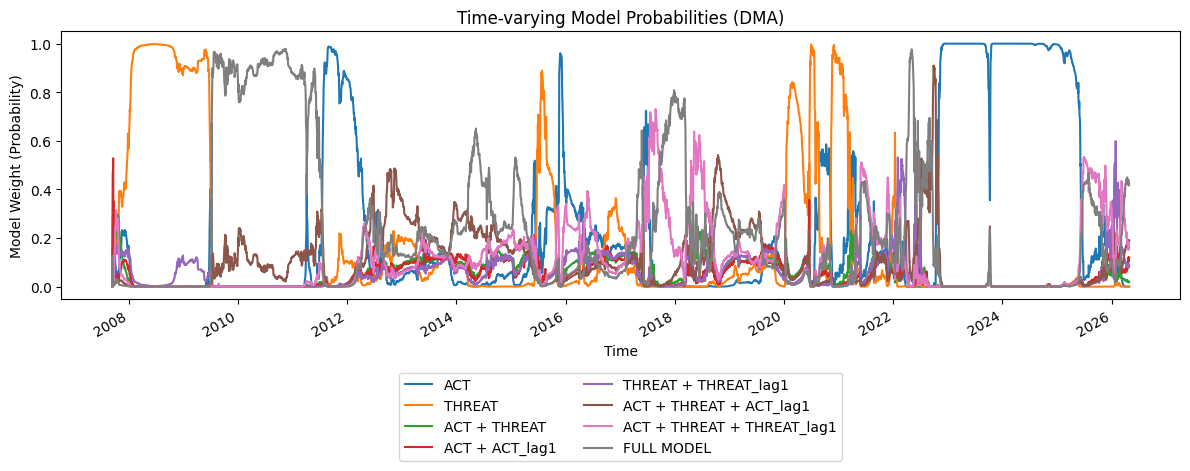

In [93]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# =========================
# 1. تاریخ واقعی
# =========================

dates = pd.to_datetime(df.index)

# =========================
# 2. importance = weights DMA
# =========================

importance = weights_time   # (T × M)

# =========================
# 3. نام مدل‌ها (دینامیک از model_list)
# =========================

model_names = [
    "ACT",
    "THREAT",
    "ACT + THREAT",
    "ACT + ACT_lag1",
    "THREAT + THREAT_lag1",
    "ACT + THREAT + ACT_lag1",
    "ACT + THREAT + THREAT_lag1",
    "FULL MODEL"
]

k = len(model_names)

# =========================
# 4. رسم نمودار
# =========================

plt.figure(figsize=(12,5))

for j in range(k):
    plt.plot(dates[:len(importance)], importance[:, j], label=model_names[j])

# =========================
# 5. تنظیمات محور زمان
# =========================

plt.gcf().autofmt_xdate()

plt.title("Time-varying Model Probabilities (DMA)")
plt.xlabel("Time")
plt.ylabel("Model Weight (Probability)")

plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.25), ncol=2)

plt.tight_layout()
plt.savefig("DMA_weights.png", dpi=300, bbox_inches='tight')
plt.show()

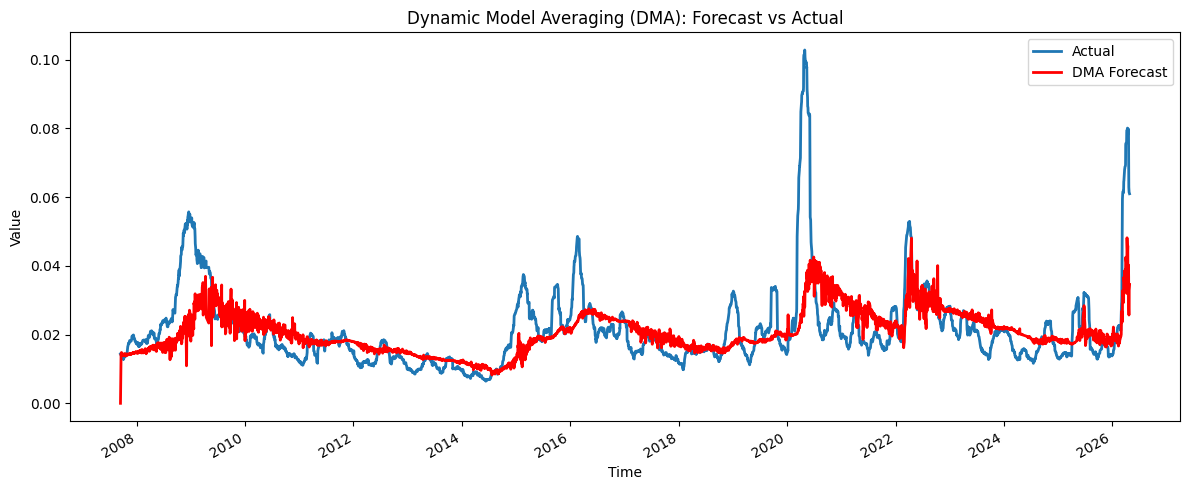

In [95]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# =========================
# 1. تاریخ
# =========================

dates = pd.to_datetime(df.index)

# =========================
# 2. هم‌تراز کردن سری‌ها
# =========================

y_plot = y.copy()
y_hat_plot = y_hat.copy()

# DMA از t=1 شروع شده → مقدار اول را حذف/NaN می‌کنیم
y_plot = y_plot[1:]
y_hat_plot = y_hat_plot[1:]
dates_plot = dates[1:]

# =========================
# 3. حذف احتمالی NaN
# =========================

mask = ~np.isnan(y_hat_plot)

y_plot = y_plot[mask]
y_hat_plot = y_hat_plot[mask]
dates_plot = dates_plot[mask]

# =========================
# 4. رسم نمودار
# =========================

plt.figure(figsize=(12,5))

plt.plot(dates_plot, y_plot, label="Actual", linewidth=2)
plt.plot(dates_plot, y_hat_plot, label="DMA Forecast", color="red", linewidth=2)

# =========================
# 5. تنظیم محور زمان
# =========================

plt.gcf().autofmt_xdate()

plt.title("Dynamic Model Averaging (DMA): Forecast vs Actual")
plt.xlabel("Time")
plt.ylabel("Value")

plt.legend()
plt.tight_layout()
plt.savefig("DMA_forecast.png", dpi=300, bbox_inches='tight')
plt.show()

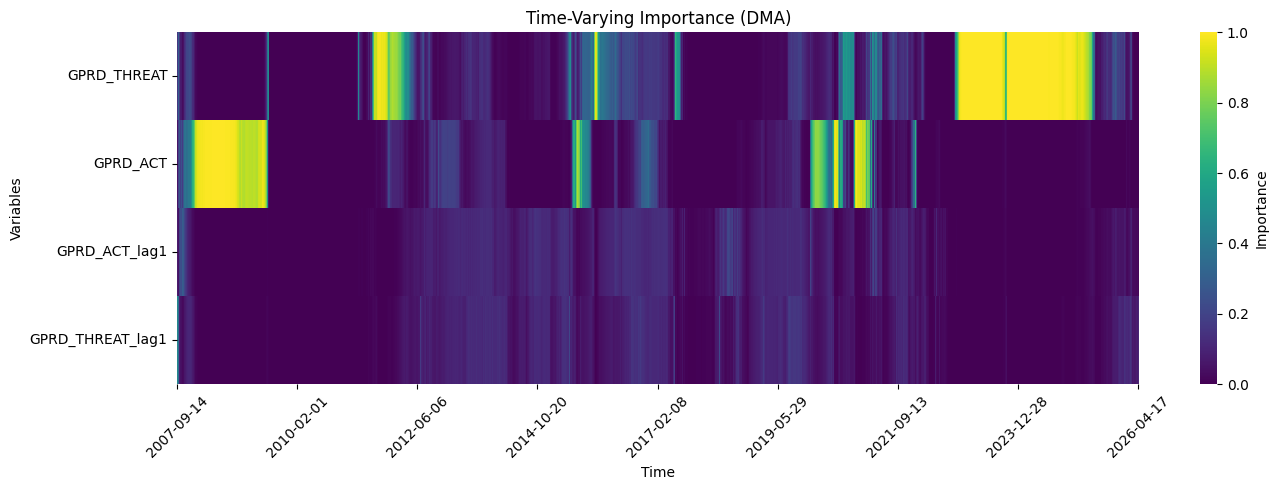

In [97]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# =========================
# 1. متغیرها
# =========================

var_names = [
    "GPRD_THREAT",
    "GPRD_ACT",
    "GPRD_ACT_lag1",
    "GPRD_THREAT_lag1"
]

# =========================
# 2. هم‌ترازی درست (مهم‌ترین بخش)
# =========================

importance_clean = importance[1:, :len(var_names)]  # حذف t=0

index_clean = pd.to_datetime(df.index)[1:1+importance_clean.shape[0]]

# =========================
# 3. ساخت DataFrame
# =========================

importance_df = pd.DataFrame(
    importance_clean,
    columns=var_names,
    index=index_clean
)

importance_df.index = importance_df.index.floor('D')

# =========================
# 4. Heatmap
# =========================

plt.figure(figsize=(14,5))

sns.heatmap(
    importance_df.T,
    cmap="viridis",
    cbar_kws={'label': 'Importance'},
    xticklabels=False
)

# =========================
# 5. محور زمان
# =========================

step = max(1, len(importance_df)//8)

plt.xticks(
    ticks=np.arange(0, len(importance_df), step),
    labels=importance_df.index[::step].strftime('%Y-%m-%d'),
    rotation=45
)

plt.title("Time-Varying Importance (DMA)")
plt.xlabel("Time")
plt.ylabel("Variables")

plt.tight_layout()
plt.show()

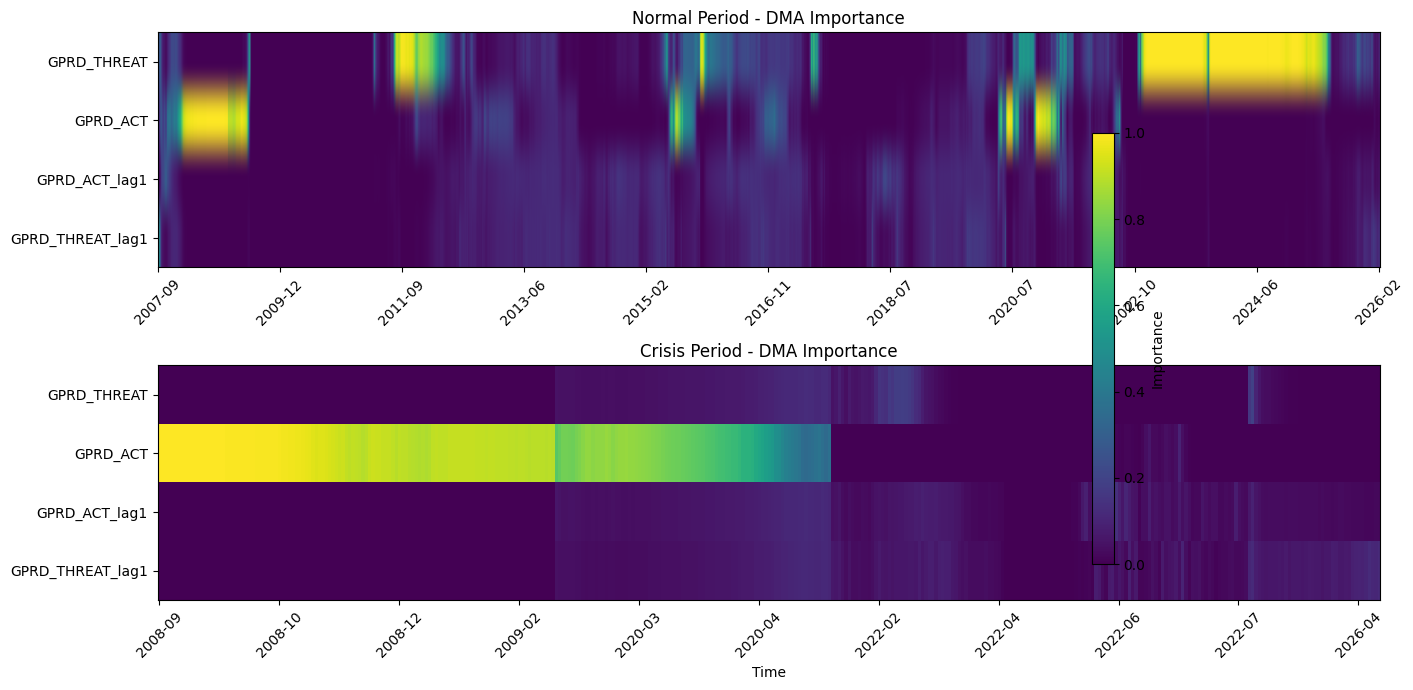

In [99]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================================================
# 1. Clean time index
# =========================================================

df = df.copy()
df = df.reset_index()

df["date"] = pd.to_datetime(df["date"])
df = df.set_index("date")
df.index = df.index.tz_localize(None)
df = df.sort_index()

# =========================================================
# 2. Align importance safely (IMPORTANT FIX)
# =========================================================

importance = np.array(importance)

n = min(len(df), importance.shape[0])

df = df.iloc[:n]
importance = importance[:n]

var_names = [
    "GPRD_THREAT",
    "GPRD_ACT",
    "GPRD_ACT_lag1",
    "GPRD_THREAT_lag1"
]

importance_df = pd.DataFrame(
    importance[:, :len(var_names)],
    columns=var_names,
    index=df.index
)

# =========================================================
# 3. Crisis definition
# =========================================================

crises = {
    "GFC": ("2008-09-01", "2009-03-01"),
    "COVID": ("2020-02-01", "2020-06-01"),
    "Ukraine": ("2022-02-01", "2022-08-01"),
    "ME_War": ("2026-02-28", "2026-04-27")
}

crises = {
    k: (pd.to_datetime(v[0]), pd.to_datetime(v[1]))
    for k, v in crises.items()
}

# =========================================================
# 4. Crisis mask (AFTER alignment)
# =========================================================

crisis_mask = np.zeros(len(importance_df), dtype=bool)

for _, (s, e) in crises.items():
    crisis_mask |= (importance_df.index >= s) & (importance_df.index <= e)

normal_df = importance_df.loc[~crisis_mask]
crisis_df = importance_df.loc[crisis_mask]

# =========================================================
# 5. Plot
# =========================================================

fig, ax = plt.subplots(2, 1, figsize=(14, 7), sharey=True)

# ---------------- NORMAL ----------------
im1 = ax[0].imshow(
    normal_df.T.values,
    aspect='auto',
    cmap='viridis'
)

ax[0].set_title("Normal Period - DMA Importance")
ax[0].set_yticks(range(len(var_names)))
ax[0].set_yticklabels(var_names)

if len(normal_df) > 0:
    step = max(1, len(normal_df)//10)
    xticks = np.arange(0, len(normal_df), step)

    ax[0].set_xticks(xticks)
    ax[0].set_xticklabels(
        normal_df.index[xticks].strftime('%Y-%m'),
        rotation=45
    )

# ---------------- CRISIS ----------------
im2 = ax[1].imshow(
    crisis_df.T.values,
    aspect='auto',
    cmap='viridis'
)

ax[1].set_title("Crisis Period - DMA Importance")
ax[1].set_yticks(range(len(var_names)))
ax[1].set_yticklabels(var_names)

if len(crisis_df) > 0:
    step = max(1, len(crisis_df)//10)
    xticks = np.arange(0, len(crisis_df), step)

    ax[1].set_xticks(xticks)
    ax[1].set_xticklabels(
        crisis_df.index[xticks].strftime('%Y-%m'),
        rotation=45
    )

# =========================================================
# 6. SINGLE colorbar (FIXED)
# =========================================================

cbar = fig.colorbar(im1, ax=ax, shrink=0.8)
cbar.set_label("Importance")

ax[1].set_xlabel("Time")

plt.tight_layout()
plt.savefig("DMA_crisis.png", dpi=300, bbox_inches='tight')
plt.show()